In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [13]:
sp500 = yf.Ticker("^GSPC")
sp500 = sp500.history(period = "max")

In [14]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-27 00:00:00-04:00,6453.890137,6453.890137,6356.080078,6368.850098,5303490000,0.0,0.0
2026-03-30 00:00:00-04:00,6403.370117,6427.310059,6316.910156,6343.720215,5458640000,0.0,0.0
2026-03-31 00:00:00-04:00,6395.879883,6539.049805,6395.879883,6528.520020,6396100000,0.0,0.0


In [15]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-03-20 00:00:00-04:00', '2026-03-23 00:00:00-04:00',
               '2026-03-24 00:00:00-04:00', '2026-03-25 00:00:00-04:00',
               '2026-03-26 00:00:00-04:00', '2026-03-27 00:00:00-04:00',
               '2026-03-30 00:00:00-04:00', '2026-03-31 00:00:00-04:00',
               '2026-04-01 00:00:00-04:00', '2026-04-02 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24680, freq=None)

<Axes: xlabel='Date'>

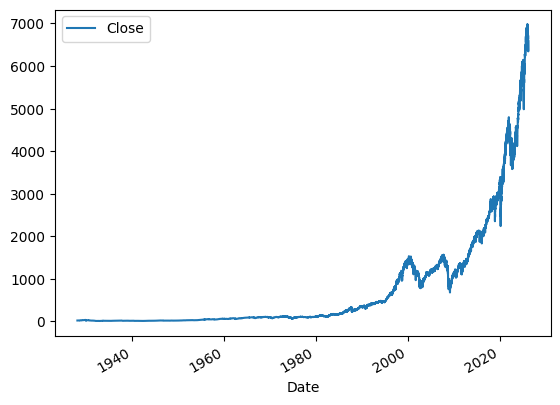

In [16]:
sp500.plot.line(y='Close',use_index = True)

In [17]:
del sp500['Dividends']
del sp500['Stock Splits']

In [18]:
sp500["Tomorrow"]= sp500['Close'].shift(-1)


In [19]:
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-03-27 00:00:00-04:00,6453.890137,6453.890137,6356.080078,6368.850098,5303490000,6343.720215
2026-03-30 00:00:00-04:00,6403.370117,6427.310059,6316.910156,6343.720215,5458640000,6528.520020
2026-03-31 00:00:00-04:00,6395.879883,6539.049805,6395.879883,6528.520020,6396100000,6575.319824


In [20]:
sp500["Target"]= (sp500["Tomorrow"]>sp500["Close"]).astype(int)

In [21]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-03-27 00:00:00-04:00,6453.890137,6453.890137,6356.080078,6368.850098,5303490000,6343.720215,0
2026-03-30 00:00:00-04:00,6403.370117,6427.310059,6316.910156,6343.720215,5458640000,6528.520020,1
2026-03-31 00:00:00-04:00,6395.879883,6539.049805,6395.879883,6528.520020,6396100000,6575.319824,1


In [22]:
sp500 = sp500.loc["1990-01-01":].copy()

In [23]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-03-27 00:00:00-04:00,6453.890137,6453.890137,6356.080078,6368.850098,5303490000,6343.720215,0
2026-03-30 00:00:00-04:00,6403.370117,6427.310059,6316.910156,6343.720215,5458640000,6528.520020,1
2026-03-31 00:00:00-04:00,6395.879883,6539.049805,6395.879883,6528.520020,6396100000,6575.319824,1


In [25]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 100, min_samples_split=100,random_state=1 )

train = sp500.iloc[:-100]
test = sp500.iloc[-100:]
predictors = ["Close","Volume","Open","High","Low"]
model.fit(train[predictors],train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [26]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])

In [28]:
preds = pd.Series(preds,index = test.index)

In [30]:
precision_score(test["Target"],preds)

0.5714285714285714

<Axes: xlabel='Date'>

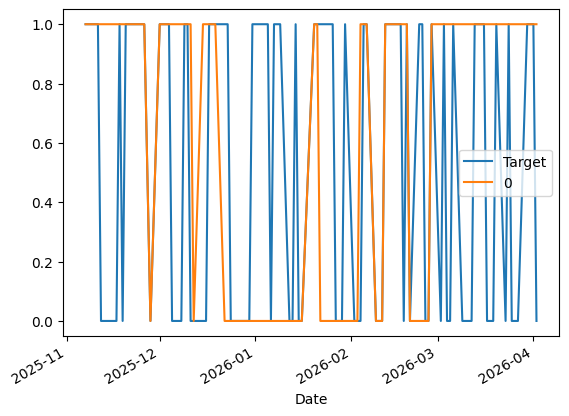

In [31]:
combined = pd.concat([test["Target"],preds],axis=1)
combined.plot()

In [33]:
def predict(train,test,predictors,model):
  model.fit(train[predictors],train["Target"])
  preds = model.predict(test[predictors])
  preds = pd.Series(preds,index = test.index,name="Predictions")
  combined = pd.concat([test["Target"],preds],axis=1)
  return combined

In [36]:
def backtest(data,model,predictors,start=2500,step=250):
  all_predictions=[]

  for i in range(start,data.shape[0],step):
    train = data.iloc[0:i].copy()
    test = data.iloc[i:(i+step)].copy()
    predictions = predict(train,test,predictors,model)
    all_predictions.append(predictions)
  return pd.concat(all_predictions)

In [38]:
predictions = backtest(sp500,model,predictors)

predictions["Predictions"].value_counts()

,count
Predictions,
0,3951
1,2679


In [39]:
precision_score(predictions["Target"],predictions["Predictions"])

0.5304217991787981

In [40]:
predictions['Target'].value_counts()/ predictions.shape[0]

,count
Target,
1,0.536953
0,0.463047


In [42]:
horizons = [2,5,60,250,1000]
new_predictors = []
for horizon in horizons:
  rolling_averages = sp500.rolling(horizon).mean()

  ratio_column = f"Close_Ratio_{horizon}"
  sp500[ratio_column] = sp500["Close"]/rolling_averages["Close"]

  trend_column = f"Trend_{horizon}"
  sp500[trend_column]=sp500.shift(1).rolling(horizon).sum()["Target"]

  new_predictors += [ratio_column,trend_column]

In [44]:
sp500 = sp500.dropna()

In [45]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-26 00:00:00-04:00,6555.859863,6573.220215,6473.790039,6477.160156,4845560000,6368.850098,0,0.991221,1.0,0.990001,2.0,0.946809,28.0,1.006745,141.0,1.258609,533.0
2026-03-27 00:00:00-04:00,6453.890137,6453.890137,6356.080078,6368.850098,5303490000,6343.720215,0,0.991569,0.0,0.977559,2.0,0.932174,28.0,0.989426,141.0,1.237121,533.0
2026-03-30 00:00:00-04:00,6403.370117,6427.310059,6316.910156,6343.720215,5458640000,6528.520020,1,0.998023,0.0,0.980846,1.0,0.929634,28.0,0.985074,140.0,1.231810,532.0


In [46]:
model = RandomForestClassifier(n_estimators = 200, min_samples_split= 50,random_state=1)


In [47]:
def predict(train,test,predictors,model):
  model.fit(train[predictors],train["Target"])
  preds = model.predict_proba(test[predictors])[:,1]
  preds[preds>=0.6]=1
  preds[preds<0.6]=0
  preds = pd.Series(preds,index=test.index, name="Predictions")
  combined = pd.concat([test["Target"],preds],axis=1)
  return combined

In [49]:
predictions = backtest(sp500,model,new_predictors )

In [50]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4751
1.0,878


In [51]:
precision_score(predictions["Target"],predictions["Predictions"])

0.571753986332574